### Objective

#### Imports

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sys

import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold, cross_val_predict, KFold
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, auc


#remove outliers (maybe)
#check imbalance (smote or undersample if needed)
#nested cross validation 

#### Load preprocessed data

In [35]:
#Load the dataset
project_root = os.path.abspath(os.path.join('..'))

if project_root not in sys.path:
    sys.path.append(project_root)


from src.preprocessing import preprocess_data

file_path = r"../data/RA_Dataset.xlsx"
output_path = r"../data/RA_dataset_cleaned.csv"

df_cleaned=preprocess_data(file_path)
df_cleaned.to_csv(output_path, index=False)

Dropping columns with > 50% missing values: smoking, tjc_28, sjc_28, vas


In [36]:
df_cleaned.columns.to_list()
df_cleaned['log_esr'] = np.log1p(df_cleaned['esr'])

#### Initial checks of the modeling dataset

In [37]:
df_cleaned.shape

(393, 52)

In [38]:
df_cleaned['target_flare_next'].value_counts()

target_flare_next
0    263
1    130
Name: count, dtype: int64

#### Define target, groups, and candidate features

In [39]:
#Define the target variable
target_variable = 'target_flare_next'

#Drop the columns that are not needed for modeling plus the target variable,
# after EDA analysis.

drop_columns = [
    target_variable,
    'patient_id',
    'visit_date', 
    'source',
    'year_of_diagnosis',
    'crp_upper_limit',
    'comorbidities',
    'csdmard_name',
    'b_ts_dmard_name',  
    'switch_reason',
    'treatment_decision',
    'birth_year'
    
]

#Define the feature matrix X 
X = df_cleaned.drop(columns = drop_columns, errors='ignore')

#Define the target variable y
y = df_cleaned[target_variable]

#Define the groups for group-aware splitting
groups = df_cleaned['patient_id']

In [40]:
print('x shape: ', X.shape)
print('y shape: ', y.shape)


x shape:  (393, 40)
y shape:  (393,)


In [41]:
continuous_features = [
    
    'disease_duration',
    'das28_score',
    'log_esr',
    'log_crp_normalized', 
    'steroid_dose',
    'age_at_visit'
    
]


binary_features=[
    'gender',
    'rf_status',
    'anti_ccp_status',
    'csdmard_use',
    'b_ts_dmard_use',
    'crp_high',
    'esr_high',
    'previous_flare',
    'steroid_use',
    'esr_missing',
    'mtx_use',
    'comorb_cardiovascular',
    'comorb_musculoskeletal',
    'comorb_neurologic_psychiatric'
]

categorical_features = [
    'treatment_decision_grouped',
    'visit_type'
]

#### Build preprocessing pipeline

Imputation

- rf status, anti-ccp status -> most frequent
- disease duration -> median

ESR  
first experiment : median + esr_missing  
second experiment : patient-specific imputation sensitivity analysis (sensitivity check)

CRP  
median + crp_missing

compare:  
model without DAS28  
model with DAS28 + missingness flag + simple imputation



imputation linear mixed  model for das28

#### Mixed model imputation for DAS28

In [42]:
group_kfold = GroupKFold(n_splits=5)
stratified_group_kfold = StratifiedGroupKFold(n_splits=5)
for i, (train_index, test_index) in enumerate(group_kfold.split(X, y, groups)):
    print(f"Fold {i}, overlap:", set(groups.iloc[train_index]).intersection(groups.iloc[test_index]))

Fold 0, overlap: set()
Fold 1, overlap: set()
Fold 2, overlap: set()
Fold 3, overlap: set()
Fold 4, overlap: set()


#### Logistic Regression


In [ ]:
# Embedded feature selection for each feature block (inside CV folds)
selector_cont = SelectFromModel(
    estimator=LogisticRegression(
        l1_ratio=1,
        solver='liblinear',
        C=0.1,
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    threshold='median'
 )

selector_bin = SelectFromModel(
    estimator=LogisticRegression(
        l1_ratio=1,
        solver='liblinear',
        C=0.1,
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    threshold='median'
 )

selector_cat = SelectFromModel(
    estimator=LogisticRegression(
        l1_ratio=1,
        solver='liblinear',
        C=0.1,
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    threshold='median'
    )

continuous_transformer_lr = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('selector', selector_cont)
 ])

binary_transformer_lr = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('selector', selector_bin)
 ])

categorical_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ('selector', selector_cat)
 ])


preprocessor_lr = ColumnTransformer(transformers=[
    ('cont', continuous_transformer_lr, continuous_features),
    ('bin', binary_transformer_lr, binary_features),
    ('cat', categorical_transformer_lr, categorical_features)
 ])

model_lr = LogisticRegression(
    l1_ratio=0,
    solver='liblinear',
    max_iter=1000,
    random_state=42
 )

model_pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor_lr),
    ('classifier', model_lr)
 ])

param_grid_lr = {
    'preprocessor__cont__selector__estimator__C': [0.01, 0.1, 1, 10],
    'preprocessor__bin__selector__estimator__C': [0.01, 0.1, 1, 10],
    'preprocessor__cat__selector__estimator__C': [0.01, 0.1, 1, 10],
    'preprocessor__cont__selector__threshold': ['median', 'mean'],
    'preprocessor__bin__selector__threshold': ['median', 'mean'],
    'preprocessor__cat__selector__threshold': ['median', 'mean'],
    'classifier__C': [0.001, 0.01, 1, 10, 100],
    'classifier__class_weight': ['balanced', None],
    'classifier__solver': ['lbfgs', 'liblinear']
 }

grid_lr = GridSearchCV(
    estimator=model_pipeline_lr,
    param_grid=param_grid_lr,
    cv=stratified_group_kfold,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
 )

grid_lr.fit(X, y, groups=groups)

print("Best params:", grid_lr.best_params_)
print("Best CV score:", grid_lr.best_score_)

best_lr = grid_lr.best_estimator_

Fitting 5 folds for each of 10240 candidates, totalling 51200 fits
Best params: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__solver': 'liblinear', 'preprocessor__bin__selector__estimator__C': 0.01, 'preprocessor__bin__selector__threshold': 'median', 'preprocessor__cat__selector__estimator__C': 10, 'preprocessor__cat__selector__threshold': 'mean', 'preprocessor__cont__selector__estimator__C': 0.1, 'preprocessor__cont__selector__threshold': 'median'}
Best CV score: 0.548994350762675


In [78]:
# selector_cont = RFE(
#     estimator=LogisticRegression(
#         l1_ratio=1,
#         solver='liblinear',
#         C=0.1,
#         class_weight='balanced',
#         max_iter=1000,
#         random_state=42
#     ),
#     n_features_to_select=4,
#     step=1
#  )


# selector_bin = RFE(
#     estimator=LogisticRegression(
#         l1_ratio=1,
#         solver='liblinear',
#         C=0.1,
#         class_weight='balanced',
#         max_iter=1000,
#         random_state=42
#     ),
#     n_features_to_select=4,
#     step=1
#  )

# continuous_transformer_lr = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler', StandardScaler()),
#     ('selector', selector_cont)
#  ])

# binary_transformer_lr = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='most_frequent')),
#     ('selector', selector_bin)
#  ])

# preprocessor_lr = ColumnTransformer(transformers=[
#     ('cont', continuous_transformer_lr, continuous_features),
#     ('bin', binary_transformer_lr, binary_features)
#  ])

# model_lr = LogisticRegression(
#     l1_ratio=0,                     
#     solver='liblinear',
#     max_iter=1000,
#     random_state=42
# )

# model_pipeline_lr = Pipeline(steps=[
#     ('preprocessor', preprocessor_lr),
#     ('classifier', model_lr)
# ])


# param_grid_lr = {
#     'preprocessor__cont__selector__estimator__C': [0.01, 0.1, 1, 10],
#     'preprocessor__bin__selector__estimator__C': [0.01, 0.1, 1, 10],
#     'preprocessor__cont__selector__n_features_to_select': [2, 3, 4],
#     'preprocessor__bin__selector__n_features_to_select': [2, 3, 4],
#     'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
#     'classifier__class_weight': ['balanced', None],
#     'classifier__solver': ['lbfgs', 'liblinear']
#  }

# grid_lr = GridSearchCV(
#     estimator=model_pipeline_lr,
#     param_grid=param_grid_lr,
#     cv=stratified_group_kfold,
#     scoring='recall',
#     n_jobs=-1,
#     verbose=2
# )

# grid_lr.fit(X, y, groups=groups)

# print("Best params:", grid_lr.best_params_)
# print("Best CV score:", grid_lr.best_score_)

# best_lr = grid_lr.best_estimator_

In [44]:
y_pred_lr = cross_val_predict(best_lr,
                            X,
                            y,
                            cv=stratified_group_kfold,
                            groups=groups,
                            method='predict')


y_prob_lr = cross_val_predict(best_lr,
                            X,
                            y,
                            cv=stratified_group_kfold,
                            groups=groups,
                            method='predict_proba')[:, 1]
                            

print(classification_report(y, y_pred_lr))
print(f"Accuracy: {accuracy_score(y, y_pred_lr):.2f}")

roc_auc = roc_auc_score(y, y_prob_lr)
print(f"ROC AUC: {roc_auc:.2f}")

              precision    recall  f1-score   support

           0       0.79      0.64      0.71       263
           1       0.48      0.66      0.55       130

    accuracy                           0.65       393
   macro avg       0.64      0.65      0.63       393
weighted avg       0.69      0.65      0.66       393

Accuracy: 0.65
ROC AUC: 0.70


In [45]:
cm = confusion_matrix(y, y_pred_lr)
cm

array([[169,  94],
       [ 44,  86]])

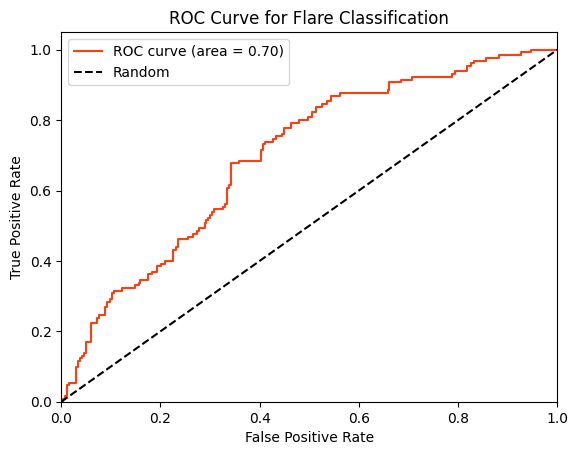

In [136]:
#Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y, y_prob_lr)
roc_auc = auc(fpr, tpr)

#Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color="#ff3f0f", lw=1.5, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Flare Classification')
plt.legend()
plt.show()

logistic regression  
penalty=l2 (ridge)  
C: the strength of regularization  
solver: liblinear, lbfgs  
max_iter = 1000  
class_weight='balanced' (if my dataset is imbalanced)  
random state: usually 42  
fit(X,y)
predict(X,y)
predict_proba(X)
score(X,y)
decision_function(X) (optional)
sample_weight (optional)


#### Random Forest

In [82]:
# Embedded feature selection with Random Forest importances
selector_rf = SelectFromModel(
    estimator=RandomForestClassifier(
        criterion='gini',
        n_estimators=300,
        random_state=42,
        n_jobs=1
    ),
    threshold='median'
)
preprocessor_rf = ColumnTransformer(transformers=[
    ('cont', continuous_transformer_lr, continuous_features),
    ('bin', binary_transformer_lr, binary_features),
    ('cat', categorical_transformer_lr, categorical_features)
 ])

model_rf = RandomForestClassifier(
    criterion='gini',
    random_state=42,
    n_jobs=1
)

model_pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('selector', selector_rf),
    ('classifier', model_rf)
])

param_grid_rf = {
    'selector__estimator__n_estimators': [100, 300],
    'selector__threshold': ['median', 'mean'],
    'classifier__n_estimators': [100, 300],
    'classifier__max_depth': [3, 5, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 3, 5],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__class_weight': ['balanced', 'balanced_subsample', None]
}

grid_rf = GridSearchCV(
    estimator=model_pipeline_rf,
    param_grid=param_grid_rf,
    cv=stratified_group_kfold,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X, y, groups=groups)

print("Best params:", grid_rf.best_params_)
print("Best CV score:", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 864 candidates, totalling 4320 fits
Best params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 3, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100, 'selector__estimator__n_estimators': 300, 'selector__threshold': 'mean'}
Best CV score: 0.67994301994302


In [83]:
y_pred_rf = cross_val_predict(best_rf,
                            X,
                            y,
                            cv=stratified_group_kfold,
                            groups=groups,
                            method='predict')


y_prob_rf = cross_val_predict(best_rf,
                            X,
                            y,
                            cv=stratified_group_kfold,
                            groups=groups,
                            method='predict_proba')[:, 1]

print(classification_report(y, y_pred_rf))
print(f"Accuracy: {accuracy_score(y, y_pred_rf):.2f}")

roc_auc = roc_auc_score(y, y_prob_rf)
print(f"ROC AUC: {roc_auc:.2f}")

              precision    recall  f1-score   support

           0       0.79      0.59      0.68       263
           1       0.45      0.68      0.54       130

    accuracy                           0.62       393
   macro avg       0.62      0.64      0.61       393
weighted avg       0.68      0.62      0.63       393

Accuracy: 0.62
ROC AUC: 0.69


In [84]:
cm = confusion_matrix(y, y_pred_rf)
cm

array([[156, 107],
       [ 42,  88]])

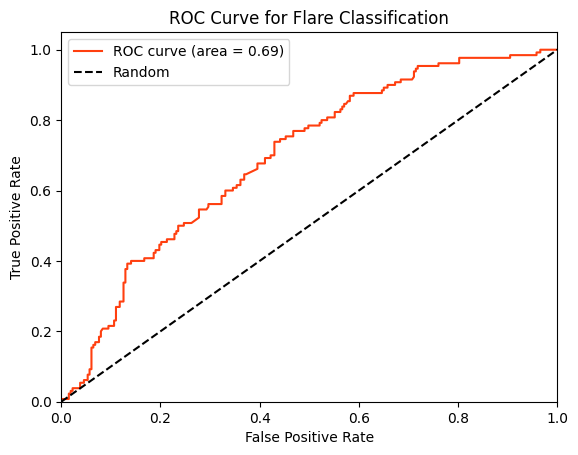

In [85]:
#Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y, y_prob_rf)
roc_auc = auc(fpr, tpr)

#Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color="#ff3f0f", lw=1.5, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Flare Classification')
plt.legend()
plt.show()

#### XGBoost
randomizedsearchCV

In [87]:
model_xgb = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=2, 
    random_state=42,
    eval_metric='auc',
    n_jobs=1
    
)

preprocessor = ColumnTransformer(transformers=[
    ('cont', continuous_transformer_lr, continuous_features),
    ('bin', binary_transformer_lr, binary_features),
    ('cat', categorical_transformer_lr, categorical_features)
 ])

model_pipeline_xgb = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', model_xgb)
])

param_grid_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [2, 3, 5],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__min_child_weight': [1, 3, 5],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    'classifier__reg_alpha': [0, 0.1, 1],
    'classifier__reg_lambda': [1, 5],
}

grid_xgb = GridSearchCV(
    estimator=model_pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=group_kfold,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X, y, groups=groups)

print("Best params:", grid_xgb.best_params_)
print("Best CV score:", grid_xgb.best_score_)

best_xgb = grid_xgb.best_estimator_


Fitting 5 folds for each of 2916 candidates, totalling 14580 fits
Best params: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 2, 'classifier__min_child_weight': 5, 'classifier__n_estimators': 100, 'classifier__reg_alpha': 1, 'classifier__reg_lambda': 5, 'classifier__subsample': 0.6}
Best CV score: 0.6736827943721634


In [88]:
y_pred_xgb = cross_val_predict(
    best_xgb,
    X,
    y,
    cv=group_kfold,
    groups=groups,
    method='predict')

y_prob_xgb = cross_val_predict(
    best_xgb,
    X,
    y,
    cv=group_kfold,
    groups=groups,
    method='predict_proba')[:, 1]

print(classification_report(y, y_pred_xgb))
print(f"Accuracy: {accuracy_score(y, y_pred_xgb):.2f}")

roc_auc = roc_auc_score(y, y_prob_xgb)
print(f"ROC AUC: {roc_auc:.2f}")

              precision    recall  f1-score   support

           0       0.76      0.62      0.68       263
           1       0.44      0.60      0.51       130

    accuracy                           0.61       393
   macro avg       0.60      0.61      0.59       393
weighted avg       0.65      0.61      0.62       393

Accuracy: 0.61
ROC AUC: 0.64


#### CatBoost

In [89]:
model_catboost = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    iterations=300,
    depth=4,
    learning_rate=0.05,
    l2_leaf_reg=3,
    random_strength=1,
    bagging_temperature=0,
    random_state=42,
    verbose=False,
    auto_class_weights='Balanced'
)

preprocessor = ColumnTransformer(transformers=[
    ('cont', continuous_transformer_lr, continuous_features),
    ('bin', binary_transformer_lr, binary_features),
    ('cat', categorical_transformer_lr, categorical_features)
 ])
model_pipeline_catboost = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', model_catboost)
])

y_pred_catboost = cross_val_predict(
    model_pipeline_catboost,
    X,
    y,
    cv=group_kfold,
    groups=groups,
    method='predict')

y_prob_catboost = cross_val_predict(
    model_pipeline_catboost,
    X,
    y,
    cv=group_kfold,
    groups=groups,
    method='predict_proba')[:, 1]

print(classification_report(y, y_pred_catboost))
print(f"Accuracy: {accuracy_score(y, y_pred_catboost):.2f}")

roc_auc = roc_auc_score(y, y_prob_catboost)
print(f"ROC AUC: {roc_auc:.2f}")

              precision    recall  f1-score   support

           0       0.70      0.73      0.72       263
           1       0.40      0.36      0.38       130

    accuracy                           0.61       393
   macro avg       0.55      0.55      0.55       393
weighted avg       0.60      0.61      0.61       393

Accuracy: 0.61
ROC AUC: 0.59


### SVM